# Select Avaiable OSC Spectra

## Library

In [59]:
import json
import glob
from astropy.table import Table, vstack
import numpy as np
from astropy import units as u
import pandas as pd
from scipy import stats
import multiprocessing as mp
import os
import warnings
warnings.filterwarnings('ignore')

In [60]:
#	Plot presetting
import matplotlib.pyplot as plt
import matplotlib as mpl
#
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [61]:
import sys
sys.path.append(os.path.join('..', 'src'))
# from util.helper import *
# from util.sdtpy import *
from helper import makeSpecColors

## Function

In [62]:
def type_mapping(outbl):
	# 타입 매핑 정의
	type_mapping = {
		# = = = = = = = = = = = = = = = = = = = = 
		#   Star
		# - - - - - - - - - - - - - - - - - - - - 
		"CV": "CV",
		"LBV": "LBV",

		# = = = = = = = = = = = = = = = = = = = = 
		#   Galaxy
		# - - - - - - - - - - - - - - - - - - - -
		"Gal": "Gal",

		# = = = = = = = = = = = = = = = = = = = = 
		#   SN
		# - - - - - - - - - - - - - - - - - - - -
		"I": "I?", "I-": "I?", "I-fain": "I?", "I-faint": "I?",
		##  Type II
		"II": "II", "II ": "II", "II/": "II", "II?": "II", "II Pec": "II",
		"Computed-IIP": "IIP", "II P": "IIP",
		"Computed-IIb": "IIb",
		"IIn/": "IIn", "IIn/LBV": "IIn", "IIn Pec": "IIn",
		##  Ia
		"Computed-Ia": "Ia", "Ia CSM": "Ia", "Ia Pe": "Ia", "Ia Pec": "Ia", "Ia-": "Ia", "Ia-02c": "Ia", "Ia-02cx": "Ia", "Ia-SC": "Ia",
		"Ia-91T": "Ia-91T",
		"Ia-91b": "Ia-91bg", "Ia-91bg": "Ia-91bg",
		"Iax[02": "Iax",
		##  Ibc
		"Ib": "Ibc", "Ib ": "Ibc", "Ib Pec": "Ibc", "Ib-Ca": "Ibc", "Ib/": "Ibc", "Ib/I": "Ibc", "Ib/c": "Ibc", "Ib/c P": "Ibc", "Ib/c Pec": "Ibc", "Ibn": "Ibc", 
		"Ic": "Ibc", "Ic ": "Ibc", "Ic BL": "Ibc", "Ic Pe": "Ibc", "Ic Pec": "Ibc", "Ic-hy": "Ibc", "Ic?": "Ibc",
		"IIb/Ib/Ic": "Ibc",
		##  PISN
		"Computed-PISN": "PISN", "PISN?": "PISN",

		# = = = = = = = = = = = = = = = = = = = = 
		#   SLSN
		# - - - - - - - - - - - - - - - - - - - -
		"SL": "SLSN", "SLS": "SLSN", "SLSN": "SLSN", "SLSN-I": "SLSN", "SLSN-II": "SLSN", "SLSN-R": "SLSN",

		# = = = = = = = = = = = = = = = = = = = = 
		#   GRB
		# - - - - - - - - - - - - - - - - - - - -
		"LGBB": "LGRB", "LG": "LGRB",
		
		# = = = = = = = = = = = = = = = = = = = = 
		#   Etc
		# - - - - - - - - - - - - - - - - - - - -
		"C": "?", "CC": "?", "c": "?", "Pec": "?", 
		"QS": "?",
		"Pec": "?",
		"--": "?",
		"Candidate": "?",
		"Imp": "?",
		"move": "Asteroid?",
	}

	# 'type' 열 생성
	outbl['type'] = outbl['claimedtype_value']

	# 매핑된 타입으로 'type' 업데이트
	for original_type, typ in type_mapping.items():
		outbl['type'][outbl['claimedtype_value'] == original_type] = typ

	# 결과 확인
	for typ in np.unique(outbl['type']):
		n_type = len(outbl[outbl['type']==typ])
		# print(f"{typ}: {n_type}")

	return outbl

In [63]:
def broad_type_mapping(outbl):
	broad_type_mapping = {
		# = = = = = = = = = = = = = = = = = = = = 
		#   SN Ia
		# - - - - - - - - - - - - - - - - - - - -
		"Ia": "Ia", 
		# "Ia-91T": "Ia-pec", 
		# "Ia-91bg": "Ia-pec", 
		# "Iax": "Ia-pec",
		"Ia-91T": "Ia", 
		"Ia-91bg": "Ia", 
		"Iax": "Ia",
		# = = = = = = = = = = = = = = = = = = = = 
		#   CCSNe
		# - - - - - - - - - - - - - - - - - - - -
		"II": "II", "IIP": "II", "IIb": "II", "IIn": "II", "Ibc": "Ibc",
		# = = = = = = = = = = = = = = = = = = = = 
		#	Variables
		# - - - - - - - - - - - - - - - - - - - -
		"CV": "CV", "LBV": "LBV",
		# = = = = = = = = = = = = = = = = = = = = 
		#   SLSN
		# - - - - - - - - - - - - - - - - - - - -
		"SLSN": "SLSN",
		"LGRB": "LGRB", 
		# = = = = = = = = = = = = = = = = = = = = 
		#   Other
		# - - - - - - - - - - - - - - - - - - - -
		# "?": "Other", "Asteroid?": "Other", "CV": "Other", "Gal": "Other", "I?": "Other", "LBV": "Other", "LGRB": "LGRB", "Unknown": "Other", "PISN": "Other",
		"Asteroid?": "Other", 
		"Gal": "Other", 
		"I?": "Other", 
		"PISN": "Other",
		"TDE": "Other", 
		# = = = = = = = = = = = = = = = = = = = = 
		#   Other
		# - - - - - - - - - - - - - - - - - - - -
		"?": "Unknown", 
		"Unknown": "Unknown", 
	}

	# 'type' 열 생성
	outbl['broad_type'] = outbl['type']

	# 매핑된 타입으로 'type' 업데이트
	for original_type, typ in broad_type_mapping.items():
		outbl['broad_type'][outbl['type'] == original_type] = typ

	# 결과 확인
	# for typ in np.unique(outbl['broad_type']):
	# 	n_type = len(outbl[outbl['broad_type']==typ])
	# 	print(f"{typ:<10}: {n_type:<5} ({n_type/len(outbl):.1%})")

	return outbl

## Path

In [64]:
PROJECT_ROOT = os.path.join(os.getcwd(), '..')
DATA = os.path.join(PROJECT_ROOT, 'data')

SPECTRA_DATA = os.path.join(DATA, 'Spectra')
SYNPHOT_DATA = os.path.join(DATA, 'Synphot')

RAW_DATA = os.path.join(DATA, 'raw_data')
RAW_OSC_DATA = os.path.join(RAW_DATA, 'OpenSupernovaCatalog')
SPECTRA_OSC_DATA = os.path.join(SPECTRA_DATA, 'OSC')

## Setting

In [65]:
keyword_to_add = [
	'claimedtype',
	'ebv',
	'host',
	'hostoffsetang',
	'hostoffsetdist',
	'hostra',
	'hostdec',
	'lumdist',
	'ra',
	'dec',
	'redshift',
	'comovingdist',
	]


# Data

In [66]:
output_table = os.path.join(SPECTRA_OSC_DATA, 'spectra_info.csv')
outbl = Table.read(output_table, format='csv',)
outbl = type_mapping(outbl)
outbl = broad_type_mapping(outbl)

# Selection

## Valid Flux 

- Flux Unit: erg/s/cm^2/Angstrom

In [67]:
print(f"Unique Flux Unit:")
indx_flux_unit = (outbl['flux_unit'] == 'erg/s/cm^2/Angstrom')
print(f"Number of spectra with flux unit 'erg/s/cm^2/Angstrom': {np.sum(indx_flux_unit)} ({np.sum(indx_flux_unit)/len(indx_flux_unit)*100:.1f}%)")
outbl['valid_flux'] = outbl['flux_unit'] == 'erg/s/cm^2/Angstrom'
np.unique(outbl['flux_unit'])

Unique Flux Unit:
Number of spectra with flux unit 'erg/s/cm^2/Angstrom': 14173 (68.1%)


?
COUNTS
DU/PIXEL
Uncalibrated
e
erg/s/cm^2/Angstrom
none gi e
none given e


In [68]:
flux_units, flux_unit_counts = np.unique(outbl['flux_unit'], return_counts=True)
# print(f"Number of flux units: {len(flux_units)}: {flux_units.value}")
# print(f"Number of objects per flux unit: {flux_unit_counts}")


In [69]:
Table([flux_units, flux_unit_counts], names=['flux_unit', 'count'])

flux_unit,count
str24,int64
?,8
COUNTS,2
DU/PIXEL,1
Uncalibrated,6627
e,6
erg/s/cm^2/Angstrom,14173
none gi e,3
none given e,1


## Wavelength Cut

- Wavelength Range: 3750 - 9000 Angstrom

In [70]:
print(f"Unique Wavelength Unit:")
print(np.unique(outbl['wavelength_unit']))

Unique Wavelength Unit:
wavelength_unit
---------------
       Angstrom


In [71]:
MIN_7DT_WAVELENGTH = 4000 - 125
MAX_7DT_WAVELENGTH = 8875 + 125

print(f"MIN_7DT_WAVELENGTH: {MIN_7DT_WAVELENGTH} - {MAX_7DT_WAVELENGTH} Angstrom")

indx_wavelength = (outbl['max_wavelength'] >= MAX_7DT_WAVELENGTH) & (outbl['min_wavelength'] <= MIN_7DT_WAVELENGTH)

outbl['within_7DT_wavelength'] = indx_wavelength

print(f"Number of spectra in 7DT wavelength range: {np.sum(indx_wavelength)} among {len(indx_wavelength)} ({np.sum(indx_wavelength)/len(indx_wavelength)*100:.1f}%)")

MIN_7DT_WAVELENGTH: 3875 - 9000 Angstrom
Number of spectra in 7DT wavelength range: 8990 among 20821 (43.2%)


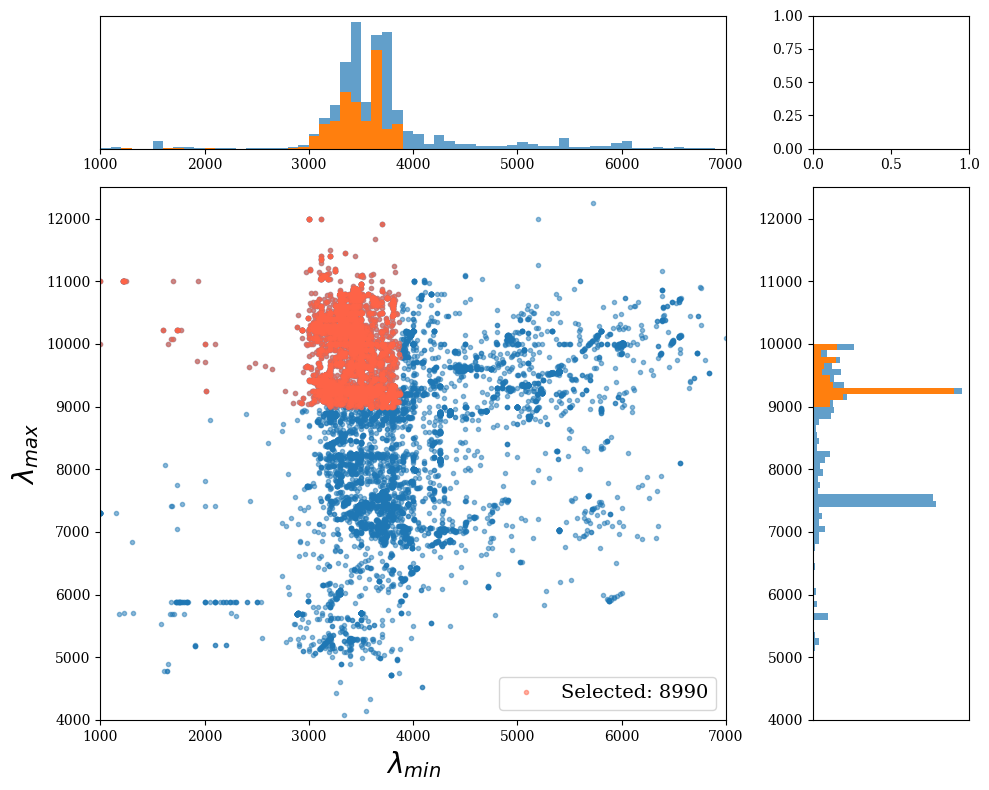

In [72]:
# 데이터 준비
min_wavelength = outbl['min_wavelength']
max_wavelength = outbl['max_wavelength']

# 히스토그램과 산점도를 위한 그리드 생성
fig, ax = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'width_ratios': [4, 1], 'height_ratios': [1, 4]})

# 산점도
ax_scatter = ax[1,0]
ax_scatter.plot(min_wavelength, max_wavelength, '.', alpha=0.5)

# 특정 조건을 만족하는 데이터 포인트를 tomato 색으로 강조
n_selected = np.sum(indx_wavelength)
ax_scatter.plot(min_wavelength[indx_wavelength], max_wavelength[indx_wavelength], '.', alpha=0.5, color='tomato', label=f"Selected: {n_selected}")

# ax_scatter.set_xscale('log')
# ax_scatter.set_yscale('log')
ax_scatter.set_xlabel(r"$\lambda_{min}$")
ax_scatter.set_ylabel(r"$\lambda_{max}$")
ax_scatter.legend(fontsize=14)

bins = np.arange(1000, 10000+100, 100)

# 위쪽 히스토그램 (min_wavelength)
ax_histx = ax[0,0]
# ax_histx.hist(min_wavelength, bins=30, alpha=0.7)
ax_histx.hist(min_wavelength, bins=bins, alpha=0.7)
ax_histx.hist(min_wavelength[indx_wavelength], bins=bins, alpha=1.0)
# ax_histx.set_xscale('log')
ax_histx.set_yticks([])

# 오른쪽 히스토그램 (max_wavelength)
ax_histy = ax[1,1]
# ax_histy.hist(max_wavelength, bins=30, orientation='horizontal', alpha=0.7)
ax_histy.hist(max_wavelength, bins=bins, orientation='horizontal', alpha=0.7)
ax_histy.hist(max_wavelength[indx_wavelength], bins=bins, orientation='horizontal', alpha=1.0)
# ax_histy.set_yscale('log')
ax_histy.set_xticks([])


# x축과 y축의 최소 및 최대 값 구하기
# x_min, x_max = 1e3, 1.5e4
x_min, x_max = 1e3, 7e3
# y_min, y_max = 1e3, 2e4
y_min, y_max = 4e3, 1.25e4

# 산점도의 x축과 y축 범위 설정
ax_scatter.set_xlim(x_min, x_max)
ax_scatter.set_ylim(y_min, y_max)

# 히스토그램의 x축과 y축 범위 설정
ax_histx.set_xlim(ax_scatter.get_xlim())  # x축 히스토그램의 범위를 산점도의 x축 범위와 동일하게 설정
ax_histy.set_ylim(ax_scatter.get_ylim())  # y축 히스토그램의 범위를 산점도의 y축 범위와 동일하게 설정


# 레이아웃 조정
plt.tight_layout()

# 그래프 보여주기
plt.show()

## Valid Flux & Wavelength Range

In [73]:
outbl['has_bad'] = [bool(val) for val in outbl['has_bad']]
outbl['has_nan'] = [bool(val) for val in outbl['has_nan']]
outbl['has_inf'] = [bool(val) for val in outbl['has_inf']]

indx_non_bad = outbl['has_bad']
print(f"Number of spectra with bad flux: {np.sum(indx_non_bad)}")

indx_non_nan = outbl['has_nan']
print(f"Number of spectra with nan flux: {np.sum(indx_non_nan)}")

indx_non_inf = outbl['has_inf']
print(f"Number of spectra with inf flux: {np.sum(indx_non_inf)}")

indx_non_outlier = indx_non_bad & indx_non_nan & indx_non_inf
print(f"Number of spectra with outlier flux: {np.sum(indx_non_outlier)} ({np.sum(indx_non_outlier)/len(indx_non_outlier)*100:.1f}%)")

outbl['has_outlier'] = indx_non_outlier

Number of spectra with bad flux: 20821
Number of spectra with nan flux: 20821
Number of spectra with inf flux: 20821
Number of spectra with outlier flux: 20821 (100.0%)


- Flux Median Value Distribution

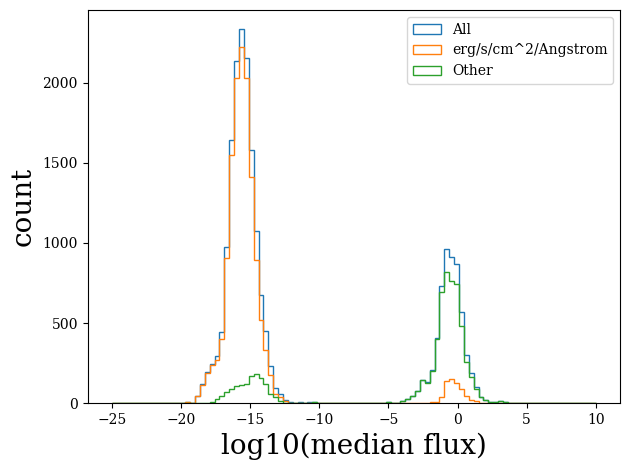

In [74]:
bins_log_flux = np.linspace(-25, 10, 100)

# outbl[outbl['flux_unit'] == 'Uncalibrated']

outbl['log10_med_flux'] = [np.log10(val) if ~np.isinf(np.log10(val)) else np.nan for val in outbl['med_flux']]

_ = plt.hist(outbl['log10_med_flux'], bins=bins_log_flux, histtype='step', label='All')
_ = plt.hist(outbl['log10_med_flux'][outbl['flux_unit'] == "erg/s/cm^2/Angstrom"], bins=bins_log_flux, histtype='step', label='erg/s/cm^2/Angstrom')
_ = plt.hist(outbl['log10_med_flux'][outbl['flux_unit'] != "erg/s/cm^2/Angstrom"], bins=bins_log_flux, histtype='step', label='Other')
plt.xlabel('log10(median flux)')
plt.ylabel('count')
plt.legend()
plt.tight_layout()



In [75]:
indx_flux = (outbl['log10_med_flux'] < -10) & (outbl['flux_unit'] == 'erg/s/cm^2/Angstrom')

- Calculate flux scaling factor

In [76]:
# indx_calibrated = outbl['log10_med_flux'] < -10
# indx_uncalibrated = outbl['log10_med_flux'] > -10 

# # Median 기준 점 계산
# left_peak_median = np.nanmedian(outbl['log10_med_flux'][indx_calibrated])
# right_peak_median = np.nanmedian(outbl['log10_med_flux'][indx_uncalibrated])

# # log scaling factor 계산
# log_scaling_factor = left_peak_median - right_peak_median

# # 초기화 및 적용 (astropy Table 기준)
# outbl['scaling_factor'] = np.ones(len(outbl))
# outbl['scaling_factor'][indx_uncalibrated] = 10.**log_scaling_factor  # log_scaling은 np.array

# print(f"Left peak median: {left_peak_median}")
# print(f"Right peak median: {right_peak_median}")
# print(f"Scaling factor: {log_scaling_factor}")


# outbl['scaling_factor'] = 1.
# outbl['scaling_factor'][indx_uncalibrated] = 10.**log_scaling_factor

# outbl['log_scaling_factor'] = np.log10(outbl['scaling_factor'])

In [77]:

# fig = plt.figure(figsize=(10,5))
# plt.subplot(121)
# _ = plt.hist(outbl['log10_med_flux'][indx_calibrated], bins=bins_log_flux)
# _ = plt.hist(outbl['log10_med_flux'][indx_uncalibrated], bins=bins_log_flux)
# plt.subplot(122)
# _ = plt.hist(outbl['log10_med_flux'][indx_calibrated], bins=bins_log_flux, histtype='step')
# _ = plt.hist(outbl['log10_med_flux'][indx_uncalibrated]+log_scaling_factor, bins=bins_log_flux, histtype='step')
# plt

In [78]:

# _ = plt.hist(outbl['log10_med_flux']+outbl['log_scaling_factor'], bins=100, label='All', histtype='step')
# _ = plt.hist(outbl['log10_med_flux'][indx_calibrated], bins=100, histtype='step', label='Calibrated', lw=3)
# _ = plt.hist(outbl['log10_med_flux'][indx_uncalibrated]+log_scaling_factor, bins=100, histtype='step', label='Uncalibrated', lw=3)
# plt.xlabel('log10(median flux)')
# plt.ylabel('count')
# plt.legend()
# plt.tight_layout()


In [79]:
# indx_flux = (outbl['log10_med_flux']+log_scaling_factor > -25) & (outbl['log10_med_flux']+log_scaling_factor < -10)
# print(f"Valid Flux Spectra: {np.sum(indx_flux)} among {len(indx_flux)} ({np.sum(indx_flux)/len(indx_flux)*100:.1f}%)")


## Final Selection

In [80]:
# indx_select = indx_wavelength & indx_flux_unit & indx_non_outlier
indx_select = indx_wavelength & indx_non_outlier & indx_flux
print(f"Selected spectra: {np.sum(indx_select)} among {len(indx_select)} ({np.sum(indx_select)/len(indx_select)*100:.1f}%)")

selected_tbl = outbl[indx_select]


Selected spectra: 5311 among 20821 (25.5%)


In [81]:
# 고유 type과 그 개수 계산
types, counts = np.unique(selected_tbl['broad_type'], return_counts=True)
print(f"Number of objects: {len(selected_tbl)}")
print(f"Number of types: {len(types)}: {types.value}")
print(f"Number of objects per type: {counts}")

Number of objects: 5311
Number of types: 9: ['CV' 'II' 'Ia' 'Ibc' 'LBV' 'LGRB' 'Other' 'SLSN' 'Unknown']
Number of objects per type: [   2 1856 2838  357    1   14  119   82   42]


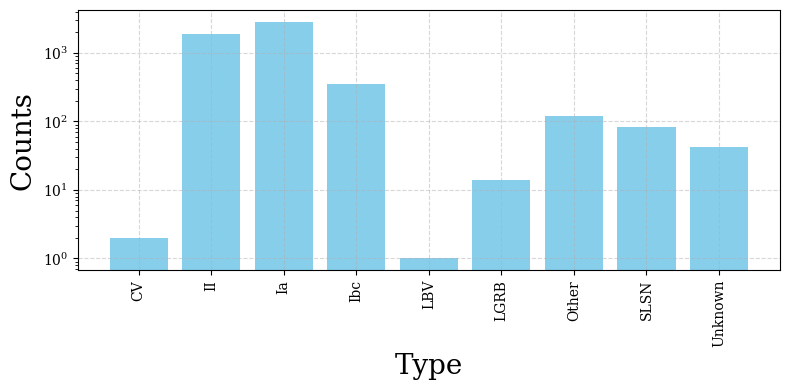

In [82]:
# 바 그래프 시각화
plt.figure(figsize=(8, 4))
plt.bar(types, counts, color='skyblue')
plt.xticks(rotation=90, ha='center')  # 글자가 겹치지 않도록 회전
plt.ylabel("Counts")
plt.xlabel("Type")
# plt.title("Count of Each Type")
plt.yscale('log')
plt.grid('both', ls='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

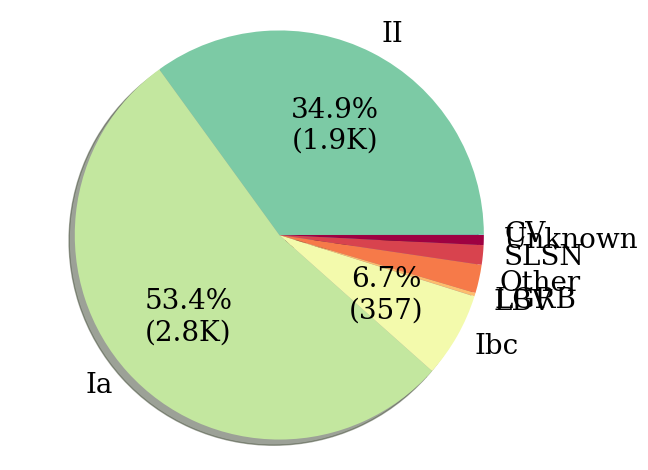

In [83]:
labels = np.unique(selected_tbl['broad_type'])
sizes = [len(selected_tbl[selected_tbl['broad_type']==typ]) for typ in np.unique(selected_tbl['broad_type'])]

colors = makeSpecColors(len(labels))

#
# 사용자 정의 함수로 퍼센티지와 숫자 표시
def make_autopct(values, fontsize=20, threshold=5):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        # 1000 이상의 숫자는 K로 표시
        val_str = f"{val/1000:.1f}K" if val >= 1000 else str(val)
        return '{p:.1f}%\n({v})'.format(p=pct, v=val_str) if pct >= threshold else ''
    return my_autopct

# 파이 차트 수정
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes, fontsize=20, threshold=5), 
        colors=colors[::-1], shadow=True, textprops={'fontsize': 20})

# 파이 차트 수정
# plt.pie(sizes, labels=labels, autopct=make_autopct(sizes, fontsize=20, threshold=5), 
#         colors=colors[::-1], shadow=True, textprops={'fontsize': 20})
#

# _ = plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors[::-1])
_ = plt.axis('equal')
# plt.title("Broad Type")
plt.tight_layout()


In [84]:
unique_type_table = Table()
unique_type_table['type'] = labels
unique_type_table['count'] = sizes
unique_type_table

type,count
str13,int64
CV,2
II,1856
Ia,2838
Ibc,357
LBV,1
LGRB,14
Other,119
SLSN,82
Unknown,42


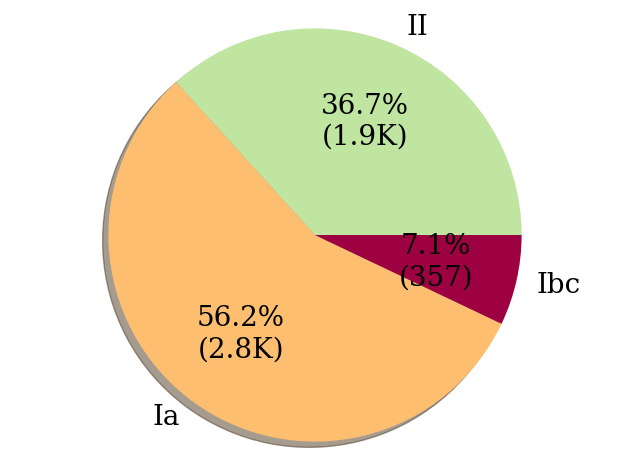

In [85]:
labels = np.unique(selected_tbl['broad_type'])
#	Remove CV, LBV, LGRB, Other, SLSN, Unknown
labels = [typ for typ in labels if typ not in ['CV', 'LBV', 'LGRB', 'Other', 'SLSN', 'Unknown']]
sizes = [len(selected_tbl[selected_tbl['broad_type']==typ]) for typ in labels]

colors = makeSpecColors(len(labels))

#
# 사용자 정의 함수로 퍼센티지와 숫자 표시
def make_autopct(values, fontsize=20, threshold=5):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        # 1000 이상의 숫자는 K로 표시
        val_str = f"{val/1000:.1f}K" if val >= 1000 else str(val)
        return '{p:.1f}%\n({v})'.format(p=pct, v=val_str) if pct >= threshold else ''
    return my_autopct

# 파이 차트 수정
plt.pie(sizes, labels=labels, autopct=make_autopct(sizes, fontsize=20, threshold=5), 
        colors=colors[::-1], shadow=True, textprops={'fontsize': 20})

# 파이 차트 수정
# plt.pie(sizes, labels=labels, autopct=make_autopct(sizes, fontsize=20, threshold=5), 
#         colors=colors[::-1], shadow=True, textprops={'fontsize': 20})
#

# _ = plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors[::-1])
_ = plt.axis('equal')
# plt.title("Broad Type")
plt.tight_layout()

In [86]:
import uuid
selected_tbl['uid'] = [str(uuid.uuid4()) for _ in range(len(selected_tbl))]
selected_tbl[:3]

jsonfile,specfile,flux_unit_flag,wavelength_unit,min_wavelength,max_wavelength,med_wavelength,std_wavelength,flux_unit,min_flux,max_flux,med_flux,std_flux,has_nan,has_inf,has_bad,path_spectra_file,claimedtype_value,claimedtype_source,ebv_value,ebv_derived,ebv_e_value,ebv_source,host_value,host_source,hostoffsetang_value,hostoffsetang_u_value,hostoffsetang_source,hostoffsetdist_value,hostoffsetdist_source,hostra_value,hostra_derived,hostra_u_value,hostra_source,hostdec_value,hostdec_derived,hostdec_u_value,hostdec_source,lumdist_value,lumdist_derived,lumdist_u_value,lumdist_source,ra_value,ra_u_value,ra_source,dec_value,dec_u_value,dec_source,redshift_value,redshift_source,comovingdist_value,comovingdist_derived,comovingdist_u_value,comovingdist_source,hostoffsetang_derived,ra_derived,dec_derived,redshift_kind,redshift_derived,claimedtype_kind,redshift_e_value,claimedtype_probability,lumdist_e_value,lumdist_kind,host_kind,ra_e_value,dec_e_value,type,broad_type,valid_flux,within_7DT_wavelength,has_outlier,log10_med_flux,uid
str142,str75,str5,str8,float64,float64,float64,float64,str24,float64,float64,float64,float64,bool,bool,bool,str144,str13,str33,float64,str4,float64,str5,str30,str71,float64,str10,str25,float64,str64,str12,str4,str5,int64,str14,str4,str7,int64,float64,str4,str3,str30,str12,str5,str20,str13,str7,str18,float64,str45,float64,str4,str3,str20,str4,str4,str4,str17,str4,str13,str8,float64,float64,str4,str7,int64,int64,str13,str13,bool,bool,bool,float64,str36
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/OpenSupernovaCatalog/sne-2015-2019-master/ASASSN-15ar.json,tPS1-15p_20150114_Gr13_Free_slit1.0_1_f.asci,True,Angstrom,3644.047852,9239.227452,5.51792899999964,4.899782998738501e-07,erg/s/cm^2/Angstrom,-1.45603e-16,8.62521e-16,2.9907e-16,1.819198202328593e-16,True,True,True,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/OSC/tPS1-15p_20150114_Gr13_Free_slit1.0_1_f.asci,Ia,"2,3,4,7,8,9,10,12,13",0.0921,True,0.0028,"6,11",CGCG 439-010,"2,3,4,7,8,9,10",21.06,arcseconds,"2,8",--,--,--,--,--,--,--,--,--,--,130.34,True,Mpc,"1,2,8,11",02:28:20.352,hours,"2,8",+10:23:03.84,degrees,"2,8",0.02882,"2,8",126.7,True,Mpc,"1,2,8,11",--,--,--,--,--,--,--,--,--,--,--,--,--,Ia,Ia,True,True,True,-15.524227149281964,57887d8e-d0ab-482e-9b78-188882d455dc
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/OpenSupernovaCatalog/sne-2015-2019-master/ASASSN-15bf.json,tASASSN-15bf_20150120_Gr13_Free_slit1.0_1_f.asci,True,Angstrom,3644.047852,9239.227452,5.51792899999964,4.899782998738501e-07,erg/s/cm^2/Angstrom,-5.33576e-17,5.28847e-16,2.07728e-16,1.4007764697606985e-16,True,True,True,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/OSC/tASASSN-15bf_20150120_Gr13_Free_slit1.0_1_f.asci,Ia,"2,3,5,6,8,9",0.0208,True,0.0007,"4,7",2MASX J04384102-4137212,"2,5",4.77,arcseconds,"2,5",4.68,"1,2,5,7,9",04:38:41.02,True,hours,7,-41:37:21.2,True,degrees,7,222.629,True,Mpc,"1,2,5,7",04:38:41.112,hours,"2,5",-41:37:26.4,degrees,"2,5",0.048527,"2,5",212.33,True,Mpc,"1,2,5,7",--,--,--,--,--,--,--,--,--,--,--,--,--,Ia,Ia,True,True,True,-15.682504960249172,7c592100-5e72-4d54-952b-67864527d978
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/OpenSupernovaCatalog/sne-2015-2019-master/ASASSN-15cb.json,tASASSN-15cb_20150125_Gr13_Free_slit1.0_1_f.asci,True,Angstrom,3644.047852,9239.227452,5.51792899999964,4.899782998738501e-07,erg/s/cm^2/Angstrom,8.68034e-18,8.11919e-16,2.97464e-16,1.8225494139033345e-16,True,True,True,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/OSC/tASASSN-15cb_20150125_Gr13_Free_slit1.0_1_f.asci,Ia,"2,3,5,6,8,9",0.0279,True,0.0014,"4,7",CGCG 042-196,"2,5,6",0.51,arcseconds,"2,5",--,--,--,--,--,--,--,--,--,--,182.565,True,Mpc,"1,2,5,7",12:39:50.16,hours,"2,5",+03:47:49.74,degrees,"2,5",0.040038,"2,5",175.54,True,Mpc,"1,2,5,7",--,--,--,--,--,--,--,--,--,--,--,--,--,Ia,Ia,True,True,True,-15.526565586397226,959368ff-d530-49cf-b142-2ac709d2d464


In [87]:
# selected_tbl.rename_column('jsonfile', 'path_spectra_file')
selected_tbl['data_from'] = 'OSC'
output_table_path = os.path.join(SPECTRA_OSC_DATA, "selected_spectra_meta_table.csv")
selected_tbl.write(output_table_path, format='csv', overwrite=True)